In [1]:
!pip install opencv-python tensorflow keras


In [2]:
import cv2
import numpy as np
import os
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt


In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [4]:
!pip install kagglehub

In [5]:
import kagglehub

path = kagglehub.dataset_download("omkargurav/face-mask-dataset")
print("Path to dataset files:", path)


Path to dataset files: /kaggle/input/face-mask-dataset


In [6]:
import os

# Use the actual path returned by kagglehub
dataset_path = '/kaggle/input/face-mask-dataset'

# List folders/files in that directory
files_in_dataset = os.listdir(dataset_path)

# Show the first 10 items
print(files_in_dataset[:10])


['data']


In [7]:
data_folder_path = os.path.join(dataset_path, 'data')

# List files in the 'data' folder
files_in_data = os.listdir(data_folder_path)

# Show the first 10 files
print(files_in_data[:10])


['without_mask', 'with_mask']


In [8]:
# Define paths for both categories
with_mask_folder = os.path.join(data_folder_path, 'with_mask')
without_mask_folder = os.path.join(data_folder_path, 'without_mask')

# List some files from both folders
with_mask_files = os.listdir(with_mask_folder)
without_mask_files = os.listdir(without_mask_folder)

print("Sample 'With Mask' files:", with_mask_files[:5])  # Show first 5 images
print("Sample 'Without Mask' files:", without_mask_files[:5])  # Show first 5 images


Sample 'With Mask' files: ['with_mask_3326.jpg', 'with_mask_3139.jpg', 'with_mask_696.jpg', 'with_mask_2867.jpg', 'with_mask_39.jpg']
Sample 'Without Mask' files: ['without_mask_3248.jpg', 'without_mask_2803.jpg', 'without_mask_650.jpg', 'without_mask_2060.jpg', 'without_mask_559.jpg']


In [9]:
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical

IMG_SIZE = 100  # Resize images to 100x100

data = []
labels = []

# Define categories
categories = ['with_mask', 'without_mask']

# Loop through the categories and load the images
for category in categories:
    folder = os.path.join(data_folder_path, category)
    label = categories.index(category)  # Assign label (0 for 'with_mask' and 1 for 'without_mask')

    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        try:
            img = cv2.imread(img_path)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))  # Resize image
            data.append(img)  # Append image to data
            labels.append(label)  # Append corresponding label
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")

# Convert data and labels to numpy arrays
data = np.array(data) / 255.0  # Normalize pixel values to 0-1
labels = np.array(labels)

# Split the data into training and testing sets (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Convert labels to categorical format (one-hot encoding)
y_train = to_categorical(y_train, num_classes=2)
y_test = to_categorical(y_test, num_classes=2)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")


Training data shape: (6042, 100, 100, 3)
Test data shape: (1511, 100, 100, 3)


In [10]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build the CNN model
model = Sequential()

# 1st Convolutional Layer
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(100, 100, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 2nd Convolutional Layer
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 3rd Convolutional Layer
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flattening
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))  # Dropout helps reduce overfitting

# Output Layer
model.add(Dense(2, activation='softmax'))  # 2 classes: with_mask, without_mask

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Show the model summary
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 98, 98, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 49, 49, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 47, 47, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 23, 23, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 21, 21, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 10, 10, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 12800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       1,638,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,732,034 (6.61 MB)

 Trainable params: 1,732,034 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 116s 603ms/step - accuracy: 0.7526 - loss: 0.5073 - val_accuracy: 0.9007 - val_loss: 0.2318
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 145s 618ms/step - accuracy: 0.9101 - loss: 0.2369 - val_accuracy: 0.9365 - val_loss: 0.1639
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 137s 592ms/step - accuracy: 0.9436 - loss: 0.1666 - val_accuracy: 0.9471 - val_loss: 0.1413
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 145s 610ms/step - accuracy: 0.9388 - loss: 0.1677 - val_accuracy: 0.9523 - val_loss: 0.1352
Epoch 5/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 143s 619ms/step - accuracy: 0.9546 - loss: 0.1424 - val_accuracy: 0.9583 - val_loss: 0.1212
Epoch 6/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 137s 592ms/step - accuracy: 0.9667 - loss: 0.0988 - val_accuracy: 0.9715 - val_loss: 0.1049
Epoch 7/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 145s 611ms/step - accuracy: 0.9667 - loss: 0.0962 - val_accuracy: 0.9643 - val_loss: 0.1098
Epoch 8/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 142s 611ms/step - accuracy: 0.9714 -

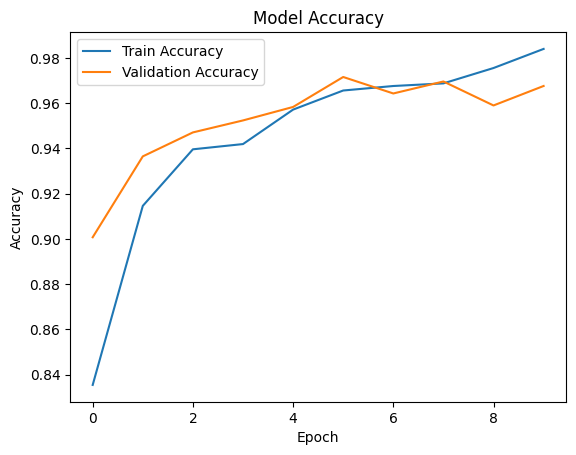

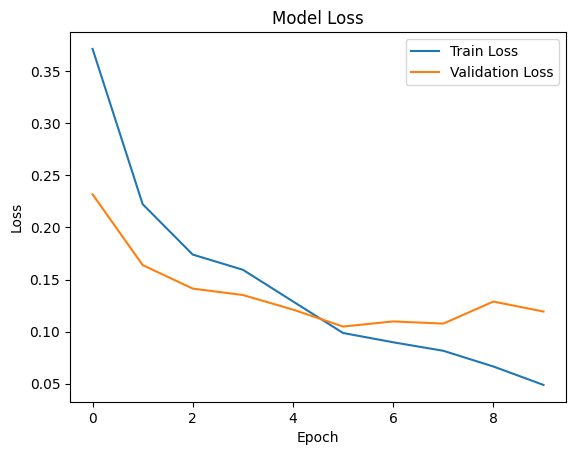

In [12]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [13]:
import os

# List all files in the current directory
print(os.listdir())


['.config', 'kaggle.json', 'sample_data']


In [14]:
import tensorflow as tf
import keras
print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

TensorFlow version: 2.18.0
Keras version: 3.8.0


In [17]:
model.save("mask_detector_model.keras")
print("✅ Model saved successfully as .keras format")


✅ Model saved successfully as .keras format


In [18]:
from keras.models import load_model

model = load_model("mask_detector_model.keras")
print("✅ Model loaded successfully")


✅ Model loaded successfully


In [19]:
from google.colab import files
files.download("mask_detector_model.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
from keras.models import load_model

model = load_model("mask_detector_model.keras")
print("✅ Model loaded successfully!")

✅ Model loaded successfully!


In [21]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
from PIL import Image
from io import BytesIO

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = '📸 Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getTracks().forEach(track => track.stop());
      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
    takePhoto(%f);
  ''' % quality)

  display(js)
  data = eval_js("takePhoto(%f)" % quality)
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename


In [26]:
print("Flattened shape:", resized.flatten().shape)


Flattened shape: (38400,)


<IPython.core.display.Javascript object>

✅ Image captured: photo.jpg


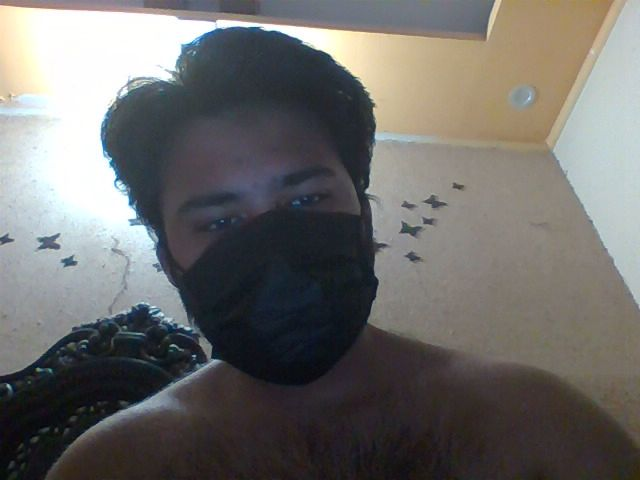

In [28]:
filename = take_photo()
print("✅ Image captured:", filename)

# Read image
img = cv2.imread(filename)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Optional: Show image (for visual check)
from google.colab.patches import cv2_imshow
cv2_imshow(img)


In [29]:
# Resize the image to (100, 100)
resized = cv2.resize(img, (100, 100))  # Resize to match model input shape (100, 100, 3)
input_img = np.expand_dims(resized, axis=0)  # Add batch dimension
input_img = input_img / 255.0  # Normalize to [0, 1]

# Check the shape of the input image
print("Input shape for prediction:", input_img.shape)

# Predict using the loaded model
result = model.predict(input_img)
print("Prediction:", result)

# Interpret result (assuming output = [mask, no_mask])
if result[0][0] > result[0][1]:
    print("😷 Mask Detected")
else:
    print("🚫 No Mask Detected")


Input shape for prediction: (1, 100, 100, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Prediction: [[0.96824574 0.03175424]]
😷 Mask Detected
